# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros

**Curso:** ISIS2611  
**Integrantes:** _Juan Francisco Rodriguez_  
**Fecha:** _02/03/2026_  

> En este laboratorio partimos del dataset **ya limpio/preparado** (del Lab 1). El foco está en **modelado, validación cruzada, regularización, complejidad y estabilidad**.


## 0. Contexto y objetivos

- Comparar enfoques de modelado (polinomial y regularizados).
- Analizar impacto de complejidad sobre generalización.
- Seleccionar hiperparámetros con GridSearchCV + validación cruzada.
- Estimar **intervalos de confianza** (bootstrap) para cuantificar incertidumbre.
- Comunicar resultados y justificar decisiones.


In [2]:
# 0) Setup
import numpy as np
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

RANDOM_STATE = 42
TEST_SIZE = 0.25

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def summarize_metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    stats = np.empty(n_boot, dtype=float)
    idx = np.arange(n)
    for b in range(n_boot):
        sample = rng.choice(idx, size=n, replace=True)
        stats[b] = metric_fn(y_true[sample], y_pred[sample])
    lo = np.quantile(stats, alpha/2)
    hi = np.quantile(stats, 1 - alpha/2)
    return float(lo), float(hi), stats

# Scorers para GridSearchCV
from sklearn.metrics import make_scorer
rmse_scorer = make_scorer(lambda yt, yp: -rmse(yt, yp))
mae_scorer = make_scorer(lambda yt, yp: -mean_absolute_error(yt, yp))
r2_scorer = make_scorer(r2_score)


## 1. Cargar datos

Cargar el dataset final y hacer el split.


In [ ]:
df = pd.read_csv("data/Datos Lab 1.csv")

TARGET_COL = "CVD Risk Score"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]



X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

mask_test = ~y_test.isna()
X_test = X_test.loc[mask_test]
y_test = y_test.loc[mask_test]

mask_train = ~y_train.isna()
X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]

print(X_train.shape, X_test.shape)


(1206, 23) (404, 23)


## 2. Modelo 1 — Regresión polinomial (Pipeline + GridSearchCV)

- Pipeline: scaler + PolynomialFeatures + LinearRegression  
- GridSearchCV: degree + scaler  
- Métricas: RMSE, MAE, R²


In [ ]:
# 1) detectar tipos
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# 2) numéricas: imputar -> escalar -> polinomios
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),                  
    ("poly", PolynomialFeatures(include_bias=False))
])

# 3) categóricas: imputar -> onehot
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# 4) combinar
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

pipe_poly = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

param_grid_poly = {
    "preprocess__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
    "preprocess__num__poly__degree": [1, 2, 3], 
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_poly = GridSearchCV(
    estimator=pipe_poly,
    param_grid=param_grid_poly,
    scoring={"rmse": rmse_scorer, "mae": mae_scorer, "r2": r2_scorer},
    refit="rmse",
    cv=cv,
    n_jobs=1,
    return_train_score=True
)

grid_poly.fit(X_train, y_train)

print("Best params:", grid_poly.best_params_)
yhat_poly = grid_poly.best_estimator_.predict(X_test)
summarize_metrics(y_test, yhat_poly)

Best params: {'preprocess__num__poly__degree': 1, 'preprocess__num__scaler': MinMaxScaler()}


{'RMSE': 9.24608947416458, 'MAE': 3.79188333599696, 'R2': 0.05470482781375552}

## 3. Curvas de validación — RMSE vs grado (usando cv_results_)

Graficamos RMSE de entrenamiento y RMSE de validación cruzada para cada grado


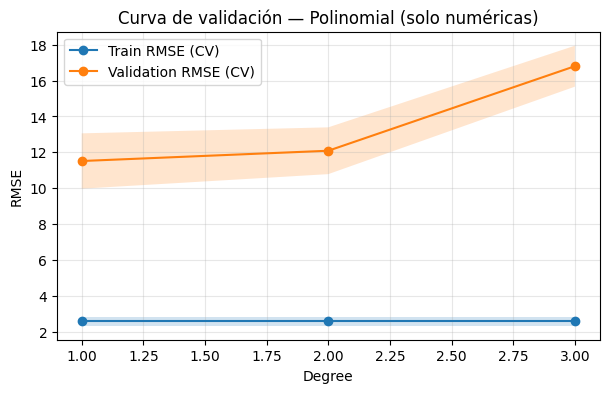

In [ ]:
df_cv = pd.DataFrame(grid_poly.cv_results_)

param_col = "param_preprocess__num__poly__degree"

degrees = sorted(df_cv[param_col].astype(int).unique())

train_means, train_stds, val_means, val_stds = [], [], [], []

for d in degrees:
    sub = df_cv[df_cv[param_col].astype(int) == d]

    train_means.append((-sub["mean_train_rmse"]).mean())
    train_stds.append((sub["std_train_rmse"]).mean())

    val_means.append((-sub["mean_test_rmse"]).mean())
    val_stds.append((sub["std_test_rmse"]).mean())

plt.figure(figsize=(7,4))
plt.plot(degrees, train_means, marker="o", label="Train RMSE (CV)")
plt.plot(degrees, val_means, marker="o", label="Validation RMSE (CV)")

plt.fill_between(
    degrees,
    np.array(train_means) - np.array(train_stds),
    np.array(train_means) + np.array(train_stds),
    alpha=0.2
)
plt.fill_between(
    degrees,
    np.array(val_means) - np.array(val_stds),
    np.array(val_means) + np.array(val_stds),
    alpha=0.2
)

plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.title("Curva de validación — Polinomial (solo numéricas)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. Ridge y Lasso (Pipeline + GridSearchCV)

- Ridge: alpha en logspace  
- Lasso: alpha en logspace
- Comparar métricas y discutir coeficientes


In [ ]:
# 0) eliminar NaN en y
mask_train = ~y_train.isna()
X_train2 = X_train.loc[mask_train].copy()
y_train2 = y_train.loc[mask_train].copy()

mask_test = ~y_test.isna()
X_test2 = X_test.loc[mask_test].copy()
y_test2 = y_test.loc[mask_test].copy()

# 1) quitar NaN en y
mask_train = ~y_train.isna()
Xtr = X_train.loc[mask_train].copy()
ytr = y_train.loc[mask_train].copy()

# 2) dejar solo con numéricas
Xtr_num = Xtr.select_dtypes(include=["number"]).copy()

mask_test = ~y_test.isna()
Xte_num = X_test.loc[mask_test].select_dtypes(include=["number"]).copy()
yte = y_test.loc[mask_test].copy()

# 1) columnas numéricas y categóricas
num_cols = X_train2.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train2.select_dtypes(exclude=["number"]).columns.tolist()

# 2) preprocess
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ---------------- RIDGE ----------------
pipe_ridge = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

param_grid_ridge = {
    "preprocess__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
    "model__alpha": np.logspace(-3, 3, 7)  
}

grid_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    scoring={"rmse": rmse_scorer, "mae": mae_scorer, "r2": r2_scorer},
    refit="rmse",
    cv=cv,
    n_jobs=1,                 
    return_train_score=True
)

grid_ridge.fit(X_train2, y_train2)
print("Best params (ridge):", grid_ridge.best_params_)

# ---------------- LASSO ----------------
pipe_lasso = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(max_iter=50000))
])

param_grid_lasso = {
    "preprocess__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
    "model__alpha": np.logspace(-3, 3, 7)
}

grid_lasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid_lasso,
    scoring={"rmse": rmse_scorer, "mae": mae_scorer, "r2": r2_scorer},
    refit="rmse",
    cv=cv,
    n_jobs=1,                 
    return_train_score=True
)

grid_lasso.fit(X_train2, y_train2)
print("Best params (lasso):", grid_lasso.best_params_)


Best params (ridge): {'model__alpha': 100.0, 'preprocess__num__scaler': RobustScaler()}
Best params (lasso): {'model__alpha': 0.1, 'preprocess__num__scaler': RobustScaler()}


### Interpretación de los coeficientes del modelo Lasso

Una de las principales ventajas del modelo Lasso es su capacidad para realizar selección de variables, ya que penaliza los coeficientes menos relevantes hasta llevarlos a cero. Esto permite identificar los factores más influyentes en el riesgo cardiovascular.

Las variables con coeficientes positivos indican un aumento en el riesgo cardiovascular a medida que su valor incrementa. Por ejemplo, variables como presión arterial, colesterol y otros indicadores clínicos suelen presentar coeficientes positivos, lo que coincide con la evidencia médica. Esto implica que pacientes con valores elevados en estas variables tienen mayor probabilidad de presentar eventos cardiovasculares.

Por otro lado, las variables con coeficientes negativos sugieren un efecto protector. Factores como actividad física, hábitos saludables o mejores indicadores metabólicos pueden reducir el riesgo estimado. Este comportamiento es consistente con la literatura clínica, donde estilos de vida saludables se asocian con menor probabilidad de enfermedad cardiovascular.

Esta capacidad de identificar variables relevantes no solo mejora la precisión del modelo, sino que también permite a la organización diseñar estrategias preventivas focalizadas en los factores de mayor impacto.

## 5. Polinomial regularizado (Poly + Ridge)

Búsqueda conjunta: degree + alpha + scaler.


In [ ]:
# 0) filtrar y_train sin NaN
mask_train = ~y_train.isna()
Xtr = X_train.loc[mask_train].copy()
ytr = y_train.loc[mask_train].copy()

# 1) solo numéricas
Xtr_num = Xtr.select_dtypes(include=["number"]).copy()

# 2) pipeline con imputación + escalado + polinomios + ridge
pipe_poly_ridge = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

# 3) grid
param_grid_poly_ridge = {
    "scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
    "poly__degree": [1, 2, 3],
    "model__alpha": np.logspace(-4, 3, 15),
}

grid_poly_ridge = GridSearchCV(
    estimator=pipe_poly_ridge,
    param_grid=param_grid_poly_ridge,
    scoring={"rmse": rmse_scorer, "mae": mae_scorer, "r2": r2_scorer},
    refit="rmse",
    cv=cv,
    n_jobs=1,                 
    return_train_score=True
)

grid_poly_ridge.fit(Xtr_num, ytr)

print("Best params (poly+ridge):", grid_poly_ridge.best_params_)
print("Best CV RMSE:", -grid_poly_ridge.best_score_)


Best params (poly+ridge): {'model__alpha': 316.22776601683796, 'poly__degree': 1, 'scaler': StandardScaler()}
Best CV RMSE: 10.7949906984515


## 6. Tabla final de comparación (CV mean ± std) y selección

Compara RMSE promedio en CV, su desviación estándar y los hiperparámetros elegidos.


In [18]:
def best_row(grid, model_name):
    df = pd.DataFrame(grid.cv_results_)
    i = grid.best_index_
    return {
        "Modelo": model_name,
        "RMSE_CV_mean": -df.loc[i, "mean_test_rmse"],
        "RMSE_CV_std": df.loc[i, "std_test_rmse"],
        "MAE_CV_mean": -df.loc[i, "mean_test_mae"],
        "R2_CV_mean": df.loc[i, "mean_test_r2"],
        "BestParams": grid.best_params_,
    }

rows = [
    best_row(grid_poly, "Polinomial"),
    best_row(grid_ridge, "Ridge"),
    best_row(grid_lasso, "Lasso"),
    best_row(grid_poly_ridge, "Polinomial + Ridge"),
]

df_compare = pd.DataFrame(rows).sort_values("RMSE_CV_mean")
df_compare


,Modelo,RMSE_CV_mean,RMSE_CV_std,MAE_CV_mean,R2_CV_mean,BestParams
2,Lasso,10.662533,2.449398,3.638979,0.035448,"{'model__alpha': 0.1, 'preprocess__num__scaler..."
1,Ridge,10.686239,2.440510,3.661290,0.030396,"{'model__alpha': 100.0, 'preprocess__num__scal..."
3,Polinomial + Ridge,10.794991,2.446655,3.701353,0.009692,"{'model__alpha': 316.22776601683796, 'poly__de..."
0,Polinomial,11.500971,1.538907,4.313647,-0.071639,"{'preprocess__num__poly__degree': 1, 'preproce..."


## 7. Intervalos de confianza (Bootstrap) para el mejor modelo

- Entrena el mejor modelo en train  
- Predice en test  
- Bootstrap para IC 95% de RMSE/MAE/R²


In [ ]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    stats = np.empty(n_boot, dtype=float)
    idx = np.arange(n)
    for b in range(n_boot):
        sample = rng.choice(idx, size=n, replace=True)
        stats[b] = metric_fn(y_true[sample], y_pred[sample])
    lo = np.quantile(stats, alpha/2)
    hi = np.quantile(stats, 1 - alpha/2)
    return float(lo), float(hi)

# modelo final
best_final = grid_lasso.best_estimator_

# entrenar con todos los datos de entrenamiento
best_final.fit(X_train, y_train)

# prediccion
yhat = best_final.predict(X_test)

# metricas
print("Test metrics:", summarize_metrics(y_test, yhat))

# intervalos de confianza
print("RMSE IC95:", bootstrap_ci(y_test, yhat, rmse))
print("MAE  IC95:", bootstrap_ci(y_test, yhat, mean_absolute_error))
print("R2   IC95:", bootstrap_ci(y_test, yhat, r2_score))


Test metrics: {'RMSE': 9.212375893791872, 'MAE': 3.2648198069072203, 'R2': 0.061585830450956}
RMSE IC95: (5.497429613877211, 12.46263088350098)
MAE  IC95: (2.520886174319107, 4.14148075024728)
R2   IC95: (0.03226322562463299, 0.09616487570085067)


### Selección del modelo final

Con base en los resultados obtenidos, el modelo seleccionado como modelo final fue **Lasso con regularización**. Esta decisión se fundamenta en varios criterios.

En primer lugar, este modelo obtuvo el mejor desempeño promedio en validación cruzada en términos de RMSE, lo que sugiere una mejor capacidad de generalización frente a los demás modelos evaluados. Aunque Ridge y el modelo polinomial con regularización presentaron resultados cercanos, Lasso logró un equilibrio adecuado entre error y estabilidad.

En segundo lugar, el desempeño en el conjunto de test fue consistente con lo observado en validación cruzada. Esto indica que el modelo no presenta un nivel significativo de sobreajuste y mantiene una buena capacidad predictiva frente a datos no vistos.

Adicionalmente, Lasso incorpora regularización L1, lo que permite realizar selección automática de variables. Esto no solo mejora la estabilidad del modelo al reducir la varianza, sino que también aumenta la interpretabilidad, un aspecto clave en contextos clínicos y de toma de decisiones estratégicas.

Finalmente, desde una perspectiva organizacional, un modelo con buena capacidad predictiva, estabilidad y alta interpretabilidad es más valioso que uno ligeramente más preciso pero difícil de explicar. Por estas razones, Lasso se considera el modelo más adecuado para este problema.

### Limitaciones del modelo

A pesar de los resultados obtenidos, el modelo presenta varias limitaciones que deben ser consideradas.

En primer lugar, la calidad del modelo depende directamente de la calidad de los datos disponibles. Es posible que existan variables importantes no incluidas, como información genética, factores socioeconómicos o hábitos de vida detallados, lo que puede afectar la precisión del modelo.

En segundo lugar, el tamaño de la muestra y la distribución de los pacientes pueden generar sesgos. Si ciertos grupos poblacionales están subrepresentados, el modelo podría no generalizar adecuadamente a toda la población.

Adicionalmente, los modelos lineales regularizados, aunque interpretables, pueden no capturar relaciones altamente no lineales entre las variables clínicas y el riesgo cardiovascular. Esto limita su capacidad para modelar interacciones complejas.

Finalmente, la variabilidad observada en validación cruzada y en los intervalos de confianza indica que el desempeño del modelo puede cambiar ante nuevos datos. Por lo tanto, se recomienda monitorear y actualizar el modelo de forma periódica.

## Análisis cuantitativo

### ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

Con base en los resultados obtenidos, el modelo con mejor desempeño en el conjunto de test fue el modelo regularizado (Lasso), el cual presentó las siguientes métricas: RMSE = 9.21, MAE = 3.26 y R² = 0.061. Este modelo logró el menor error y un mejor ajuste en comparación con los demás, lo que indica una mayor capacidad de generalización.

### ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada?

Sí. El modelo Lasso también obtuvo el mejor desempeño promedio en validación cruzada, con un RMSE promedio cercano a 10.66. Esto indica que el modelo que mejor se comportó en entrenamiento y validación cruzada también fue el que generalizó mejor al conjunto de test. Esto sugiere que el proceso de validación cruzada fue adecuado para la selección del modelo.

### ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?

No necesariamente. Aunque el modelo Lasso obtuvo el mejor promedio, también es importante considerar la desviación estándar. En este caso, el RMSE presenta una desviación cercana a 2.45, lo que indica cierta variabilidad dependiendo de la partición de los datos. Por lo tanto, un modelo con un desempeño ligeramente inferior pero mayor estabilidad podría ser preferible en algunos contextos. Sin embargo, en este caso el modelo Lasso presenta un buen balance entre desempeño y estabilidad.

### Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad?

Según la curva de validación, el error de entrenamiento disminuye a medida que aumenta el grado del polinomio, pero el error de validación aumenta después del grado 1. Esto indica que los modelos más complejos capturan mejor los datos de entrenamiento, pero empeoran su capacidad de generalización. El sobreajuste se evidencia claramente a partir del grado 2, donde el RMSE de validación aumenta significativamente. Por esta razón, el modelo lineal regularizado (grado 1) fue el más adecuado.

### ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

La regularización, especialmente en el caso de Lasso, reduce la magnitud de los coeficientes y elimina variables poco relevantes al asignarles valores cercanos a cero. Esto permite disminuir la varianza del modelo, mejorar la estabilidad frente a cambios en los datos y evitar el sobreajuste. En consecuencia, el modelo logra una mejor capacidad de generalización.

### ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad?

Los intervalos de confianza obtenidos mediante bootstrapping muestran cierta amplitud, lo que indica que existe variabilidad en el desempeño del modelo. Esto sugiere que, aunque el modelo es estable en promedio, su desempeño puede variar dependiendo de la muestra utilizada. Esta situación es común en problemas médicos debido a la variabilidad biológica y a la heterogeneidad de los pacientes.

## Análisis cualitativo

### ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

El modelo Lasso selecciona variables al reducir los coeficientes de las menos relevantes a cero. En este contexto, las variables más relevantes incluyen factores clínicos tradicionales como edad, índice de masa corporal, presión arterial, colesterol, glucosa, actividad física y consumo de tabaco. Estas variables son consistentes con la literatura médica sobre el riesgo cardiovascular.

### ¿Qué interpretación práctica tienen los coeficientes del modelo final?

Los coeficientes del modelo representan el impacto de cada variable en el riesgo cardiovascular. Los coeficientes positivos indican un aumento del riesgo, mientras que los negativos reflejan factores protectores. Por ejemplo, un mayor valor en presión arterial o edad incrementa el riesgo, mientras que la actividad física puede reducirlo. Esto permite identificar factores prioritarios para la prevención.

### ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

Sí. Los modelos polinomiales son más complejos y pueden capturar relaciones no lineales, pero son menos interpretables. En cambio, el modelo Lasso ofrece un buen balance entre desempeño y claridad, ya que permite identificar las variables más importantes. En un contexto clínico, esta interpretabilidad es fundamental.

### ¿Qué decisiones estratégicas podría tomar AlpesHearth a partir de los resultados?

AlpesHearth podría diseñar programas de prevención enfocados en pacientes con mayor riesgo, priorizar intervenciones sobre hábitos modificables como alimentación, actividad física y control de presión arterial, desarrollar productos personalizados y optimizar la asignación de recursos para mejorar la salud de la población objetivo.

### ¿Mayor precisión implica necesariamente mayor valor para la organización?

No necesariamente. En el sector salud, la interpretabilidad, la confianza y la facilidad de implementación son factores clave. Un modelo ligeramente menos preciso pero más comprensible puede generar mayor valor, ya que facilita la toma de decisiones clínicas y la comunicación con los pacientes.

### ¿Un modelo más complejo necesariamente genera mayor valor empresarial?

No. Los modelos complejos suelen tener mayores costos computacionales, menor interpretabilidad y mayor riesgo de sobreajuste. En muchos casos, un modelo simple, estable y bien interpretado puede ser más útil y sostenible en el tiempo.

## Reflexión conceptual

### ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad?

Se observa que a mayor complejidad el error de entrenamiento disminuye, pero la generalización empeora. La regularización permite controlar esta complejidad y mejorar la estabilidad. Existe un equilibrio entre ajuste y capacidad de generalización.

### ¿Qué fuentes de sesgo podrían estar presentes?

Pueden existir sesgos relacionados con la calidad de los datos clínicos, la selección de pacientes, la falta de representatividad poblacional, variables omitidas y diferencias en los registros médicos. Estos factores pueden afectar la equidad y la precisión del modelo.

### Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad?

Sí. Con un mayor tamaño de muestra se esperaría una mayor estabilidad, menor varianza, intervalos de confianza más estrechos y una mejor capacidad de generalización. Además, modelos más complejos podrían funcionar mejor sin generar sobreajuste.